In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.width', 200)
pd.set_option('display.max_rows', 80)

df = pd.read_csv('data/survey.csv')
df.shape

(5000, 16)

### 1. Exploring data

In [3]:
# What features are there, what does the data look like, etc.
df.head(3)

,ResponseId,Age,EdLevel,Employment,WorkExp,YearsCode,DevType,OrgSize,ICorPM,RemoteWork,Industry,Country,Currency,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,annual_salary_usd
0,1,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,8.0,14.0,"Developer, mobile",20 to 99 employees,People manager,Remote,Fintech,Ukraine,EUR European Euro,Bash/Shell (all shells);Dart;SQL,Cloud Firestore;PostgreSQL,61256.0
1,10004,55-64 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,40.0,46.0,"Developer, full-stack","10,000 or more employees",Individual contributor,"Your choice (very flexible, you can come in wh...",Computer Systems Design and Services,Germany,EUR European Euro,C#;Java;SQL,H2;MariaDB;Neo4J;Oracle,99773.0
2,10016,25-34 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,2.0,5.0,"Developer, full-stack","10,000 or more employees",Individual contributor,Remote,Healthcare,United States of America,USD United States dollar,Bash/Shell (all shells);C#;HTML/CSS;JavaScript...,Microsoft SQL Server;MongoDB,85000.0


In [4]:
# Looking at data types, nulls, unique values count
print("total length: ", len(df))
pd.DataFrame({
    'dtype':  df.dtypes,
    'nulls':  df.isna().sum(),
    'null%': (df.isna().mean() * 100).round(1),
    'unique': df.nunique(),
})

total length:  5000


,dtype,nulls,null%,unique
ResponseId,int64,0,0.0,5000
Age,object,0,0.0,7
EdLevel,object,5,0.1,8
Employment,object,0,0.0,6
WorkExp,float64,52,1.0,54
YearsCode,float64,21,0.4,57
DevType,object,0,0.0,32
OrgSize,object,530,10.6,9
ICorPM,object,602,12.0,2
RemoteWork,object,553,11.1,5


### What the columns mean

| Column | Meaning |
|---|---|
| `ResponseId` | Survey row ID — no signal |
| `Age` | Age bracket |
| `EdLevel` | Highest education completed |
| `Employment` | Employed / freelance / student / not employed / retired |
| `WorkExp` | Years of professional experience |
| `YearsCode` | Years coding at all, incl. hobby — starts earlier, so runs higher |
| `DevType` | Job role (32 values) |
| `OrgSize` | Employer headcount bracket |
| `ICorPM` | Individual contributor vs. people manager |
| `RemoteWork` | Remote / hybrid / in-person |
| `Industry` | Employer sector (15 values) |
| `Country` | Country of residence (130 values) |
| `Currency` | Currency pay was reported in |
| `LanguageHaveWorkedWith` | Languages used in past year, `;`-separated |
| `DatabaseHaveWorkedWith` | Databases used in past year, `;`-separated |
| `annual_salary_usd` | **Target** — annual pay converted to USD |

Immediate takeaways:
- Most columns are text, need to do encoding
- This is a FORM:
    - Some questions are optional (null fields): edlevel, workexp (people can be unemployed), etc.
    - There are conditional sections
- Language have worked with/db have worked with have a lot of unique values, they are not categories

In [5]:
print("duplicate rows:", df.duplicated().sum())
print("duplicate response ids:", df.ResponseId.duplicated().sum())

duplicate rows: 0
duplicate response ids: 0


### 2. The target: `annual_salary_usd`

In [6]:
# Looking for null rows, descriptive stats, percentiles
s = df['annual_salary_usd']
print('missing:', s.isna().sum())
print(s.describe().round(0))
s.quantile([0, .001, .01, .05, .25, .5, .75, .95, .99, .999, 1]).round(0)

missing: 84
count       4916.0
mean       98353.0
std       145434.0
min            1.0
25%        41765.0
50%        77559.0
75%       123993.0
max      6890299.0
Name: annual_salary_usd, dtype: float64


0.000          1.0
0.001          3.0
0.010         86.0
0.050       3988.0
0.250      41765.0
0.500      77559.0
0.750     123993.0
0.950     232029.0
0.990     500000.0
0.999    1291669.0
1.000    6890299.0
Name: annual_salary_usd, dtype: float64

We note here:
- Some rows have null target values
- Most salaries fall under 500k (99%)
- The interquartile range is between 41765.0 and 123993.0 (some major outliers, both small and big)

In [7]:
# Lowest salaries (trolls?)
df.nsmallest(5, 'annual_salary_usd')[['Country', 'Currency', 'Employment', 'WorkExp', 'annual_salary_usd']]

,Country,Currency,Employment,WorkExp,annual_salary_usd
306,Indonesia,IDR\tIndonesian rupiah,Employed,5.0,1.0
2192,Colombia,COP\tColombian peso,"Independent contractor, freelancer, or self-em...",1.0,1.0
2842,China,CNY\tChinese Yuan Renminbi,Employed,8.0,1.0
3766,Bangladesh,USD United States dollar,Employed,16.0,2.0
3142,Taiwan,TWD New Taiwan dollar,Employed,8.0,3.0


In [8]:
# Some of the highest salaries
df.nlargest(5, 'annual_salary_usd')[['Country', 'Currency', 'Employment', 'WorkExp', 'annual_salary_usd']]

,Country,Currency,Employment,WorkExp,annual_salary_usd
3236,Ukraine,UAH Ukrainian hryvnia,"Independent contractor, freelancer, or self-em...",15.0,6890299.0
1858,India,USD United States dollar,Employed,6.0,2500000.0
2896,United States of America,USD United States dollar,Employed,15.0,2000000.0
4493,United States of America,USD United States dollar,Employed,11.0,1950000.0
3294,Finland,EUR European Euro,Employed,20.0,1740220.0


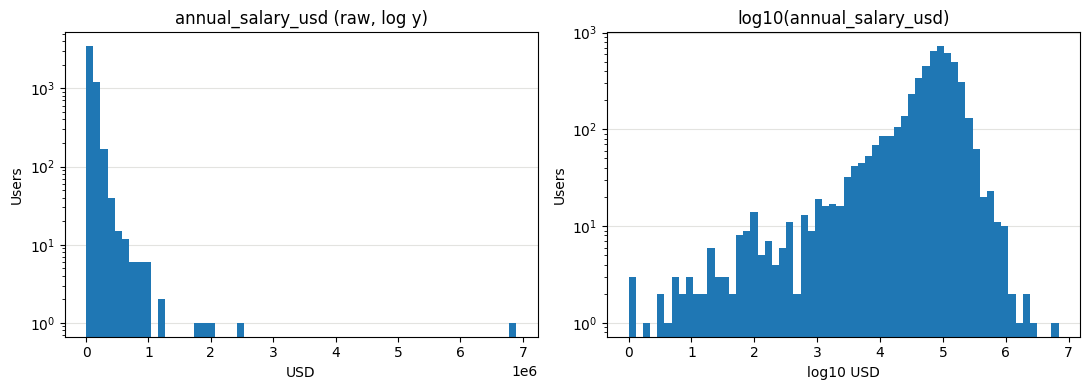

In [9]:
# Plotting histogram
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Raw salary vs. number of users
axes[0].hist(s.dropna(), bins=60)
axes[0].set_yscale('log')
axes[0].set_title('annual_salary_usd (raw, log y)')
axes[0].set_xlabel('USD')

# Logged salary vs. number of users
log_s = np.log10(s[s > 0])
axes[1].hist(log_s, bins=60)
axes[1].set_yscale('log')
axes[1].set_title('log10(annual_salary_usd)')
axes[1].set_xlabel('log10 USD')

for ax in axes:
    ax.set_ylabel('Users')
    ax.grid(axis='y', color='#E3E3E0', linewidth=0.8)
    ax.set_axisbelow(True) # put lines in background
plt.tight_layout()

There is a long right tail on the left histogram, indicating significant right skew.
- This somewhat makes sense, since this is salary data (there's minimum wage, but there's also a less bounded ceiling for high earners)
- Logging the number of users will help with this, see right histogram

There are probably also a lot of liars, so we will trim everything outside of the bounds $504-$3M.
    
- $504 is the lowest minimum wage of the participating countries, [Nigeria](https://employsome.com/blog/minimum-wage-nigeria/)
- $3M is 3x the highest recorded salary on [levels.fyi](https://www.levels.fyi/leaderboard/Software-Engineer/Entry-Level-Engineer/country/United-States/) (~$1M)

Results of applying these changes are as follows:

In [10]:
s = s[s > 0] # drop all rows w/ no target value
cleaned_s = s[(s > 504) & (s < 3e6)] # trim bounds
cleaned_s = np.log10(cleaned_s) # log target

print("raw salaries skew: ", stats.skew(s))
print("cleaned salaries skew:", stats.skew(cleaned_s))

raw salaries skew:  23.839067699686105
cleaned salaries skew: -1.3434563009351552


## 3. Data features

### 3.1 Country & Currency

In [11]:
print('countries:', df.Country.nunique())
print('countries with <100 rows:', (df.Country.value_counts() < 100).sum())
df.Country.value_counts().head(20)

countries: 130
countries with <100 rows: 117


Country
United States of America                                1089
Germany                                                  441
United Kingdom of Great Britain and Northern Ireland     316
India                                                    262
France                                                   223
Canada                                                   175
Ukraine                                                  161
Brazil                                                   132
Italy                                                    130
Netherlands                                              127
Poland                                                   121
Australia                                                119
Spain                                                    114
Sweden                                                    96
Switzerland                                               78
Czech Republic                                            68
Hungary         

There are 130 countries, but we see that only the top 13 countries have >100 responses.
- Instead of adding 130 one-hot encoding columns, we can just take the top 15, and group everything else into "other" (Sweden and Switzerland are close enough)
- The other countries are rare and have a sample size that is too restrictive, which could lead to overfitting

### 3.2 Employment

In [35]:
df.Employment.value_counts()

Employment
Employed                                                4215
Independent contractor, freelancer, or self-employed     589
Not employed                                              90
Student                                                   85
I prefer not to say                                       11
Retired                                                   10
Name: count, dtype: int64

Since "I prefer not to say" is too vague and everything else implies that they are unemployed, we can remove all rows except for the ones that are "employed" or "freelancer". These two also happen to be the majority classes.

### 3.3 WorkExp and YearsCode

In [ ]:
corr = df[['WorkExp', 'YearsCode']].corr()
print('\ncorrelation:', corr.iloc[0, 1].round(3))


correlation: 0.889


Correlation is quite high; these two columns represent roughly the same thing, so we can get rid of YearsCode later.

In [45]:
#  looking for unrealistic values
print(df[['WorkExp', 'YearsCode']].describe().round(1))
print('rows at upper bound:', ((df.WorkExp >= 50)).sum())
print('rows at lower bound:', ((df.WorkExp <= 0)).sum())

       WorkExp  YearsCode
count   4948.0     4979.0
mean      13.1       17.7
std        9.7       10.5
min        1.0        1.0
25%        6.0       10.0
50%       11.0       15.0
75%       18.0       25.0
max      100.0      100.0
rows at upper bound: 10
rows at lower bound: 0


Most people work for 40-45 years before they retire. ~50 seems like a reasonable estimate for an upper bound, so we will remove all rows greater than this.

In [52]:
# null columns
print('null values: ', df.WorkExp.isna().sum())

# checking if this a conditional field (unemployed people shouldn't have to fill this out)
rate = pd.crosstab(df.Employment, df.WorkExp.isna(), normalize='index')[True]
print('WorkExp blank rate by Employment (%):')
print(rate.mul(100).round(1).sort_values(ascending=True))

null values:  52
WorkExp blank rate by Employment (%):
Employment
Retired                                                  0.0
Independent contractor, freelancer, or self-employed     0.2
Employed                                                 0.8
Not employed                                             1.1
Student                                                 17.6
I prefer not to say                                     27.3
Name: True, dtype: float64


There are some null values this is a conditional field; unemployed people left this blank. Since we remove these rows from the previous section, this should be fine. We deal with null values in our choice of model (explained below).

### 3.4 Age, EdLevel, OrgSize

In [57]:
for col in ['Age', 'EdLevel', 'OrgSize']:
    print(df[col].value_counts(dropna=False), '\n')

Age
25-34 years old      1892
35-44 years old      1578
45-54 years old       664
18-24 years old       545
55-64 years old       270
65 years or older      45
Prefer not to say       6
Name: count, dtype: int64 

EdLevel
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          2283
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       1464
Some college/university study without earning a degree                                 578
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                         242
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)     212
Associate degree (A.A., A.S., etc.)                                                    150
Other (please specify):                                                                 48
Primary/elementary school                                                               18
NaN                                               

These look like multiple choice questions. Since they are all ordinal data, we will use integer encoding.
- For EdLevel, we can just to 1-7 and fill null values with the median
- OrgSize also has some null values. We will use add_indicator here, since we can't just take the median in all cases (could be a freelancer)
- For the others, we use the midpoint value of each option to convey differences between options
- EdLevel may be correlated with age/working experience and vice versa. We might have to do something about this, but it will depend on the type of model we pick

### 3.5 Language and DB have worked with

In [71]:
langs = df.LanguageHaveWorkedWith.dropna().str.split(';').explode()
print('distinct languages:', langs.nunique())
langs.value_counts().head(20)

distinct languages: 42


LanguageHaveWorkedWith
JavaScript                 3213
HTML/CSS                   2957
SQL                        2895
Python                     2621
TypeScript                 2329
Bash/Shell (all shells)    2270
C#                         1382
Java                       1372
PowerShell                 1088
C++                         968
Go                          856
PHP                         838
C                           824
Rust                        700
Kotlin                      532
Lua                         378
Ruby                        320
Groovy                      244
Assembly                    239
Swift                       237
Name: count, dtype: int64

In [70]:
dbs = df.DatabaseHaveWorkedWith.dropna().str.split(';').explode()
print('distinct dbs:', dbs.nunique())
dbs.value_counts().head(10)

distinct dbs: 30


DatabaseHaveWorkedWith
PostgreSQL              2371
MySQL                   1577
SQLite                  1483
Redis                   1300
Microsoft SQL Server    1259
MongoDB                  926
MariaDB                  836
Elasticsearch            777
Dynamodb                 439
Oracle                   400
Name: count, dtype: int64

A user can know multiple dbs/multiple languagse, so this is a "select all that apply" type input. We can use multi-hot encoding here for both.
- I want to avoid lumping rarer languages/dbs into an "other" column here, since a rare language (e.g. COBOL) could mean high pay or that the language is obsolete/no longer in demand

### 3.7 DevType, RemoteWork, ICorPM, ResponseId

In [79]:
for col in ['DevType', 'RemoteWork', 'ICorPM']:
    print(f'{col} ({df[col].nunique()} values):')
    print(df[col].value_counts(dropna=False).head(10), '\n')

DevType (32 values):
DevType
Developer, full-stack                            1790
Developer, back-end                               932
Architect, software or solutions                  356
Developer, front-end                              253
Developer, desktop or enterprise applications     251
Developer, mobile                                 192
Developer, embedded applications or devices       182
DevOps engineer or professional                   134
Engineering manager                               121
AI/ML engineer                                     97
Name: count, dtype: int64 

RemoteWork (5 values):
RemoteWork
Remote                                                                          1554
Hybrid (some remote, leans heavy to in-person)                                   894
Hybrid (some in-person, leans heavy to flexibility)                              819
In-person                                                                        613
Your choice (very flexible, y

- Drop ResponseId, useless
- One-hot remaining three, none of these are ordinal
- DevType: Same approach as Country for DevType; keep the top 12 roles and group the rest into "Other" to prevent overfitting on rows with too few samples
- RemoteWork: keep all 5 levels, fill in blanks with "missing" label since it could mean it doesn't apply

## 4. Cleaning — applying the decisions above

Everything here traces back to a decision recorded in section 3. Nothing new gets decided in
this section.

In [20]:
clean = df.copy()

# --- rows -------------------------------------------------------------------
# No target -> nothing to learn from (84 rows).
clean = clean[clean.annual_salary_usd.notna()]

# Section 2: implausible as an *annual* salary. Lower bound is Nigeria's minimum
# wage (the lowest of any country here), upper bound is 3x the highest salary
# recorded on levels.fyi -- deliberately loose, so it only cuts the impossible.
clean = clean[clean.annual_salary_usd.between(504, 3_000_000)]

# Section 3.2: students / not-employed / retired are answering a different
# question than "what does a working developer earn".
clean = clean[clean.Employment.isin([
    'Employed',
    'Independent contractor, freelancer, or self-employed',
])]

# --- fixes ------------------------------------------------------------------
# Section 3.3: "nobody has worked 50+ years" is a human bound I can justify.
# Set to NaN rather than dropping the row -- one bad number doesn't invalidate
# a person's country, role and education.
clean.loc[clean.WorkExp   > 50, 'WorkExp']   = np.nan
clean.loc[clean.YearsCode > 60, 'YearsCode'] = np.nan

# Section 3.4: ordered buckets stored as text -> one number each, so the model
# gets the ordering for free. Anything NOT in these maps is an escape hatch
# ("Prefer not to say", "Other", "I don't know") and .map() sends it to NaN --
# correct, because it has no place on the scale.
ED_RANK = {
    'Primary/elementary school': 1,
    'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)': 2,
    'Some college/university study without earning a degree': 3,
    'Associate degree (A.A., A.S., etc.)': 4,
    'Bachelor’s degree (B.A., B.S., B.Eng., etc.)': 5,
    'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)': 6,
    'Professional degree (JD, MD, Ph.D, Ed.D, etc.)': 7,
}
# Midpoints, not 0/1/2/3 -- the gap from "<20" to "10,000+" is not one step.
ORG_MID = {
    'Just me - I am a freelancer, sole proprietor, etc.': 1,
    'Less than 20 employees': 10,       '20 to 99 employees': 50,
    '100 to 499 employees': 300,        '500 to 999 employees': 750,
    '1,000 to 4,999 employees': 2_500,  '5,000 to 9,999 employees': 7_500,
    '10,000 or more employees': 20_000,
}
AGE_MID = {
    '18-24 years old': 21, '25-34 years old': 30, '35-44 years old': 40,
    '45-54 years old': 50, '55-64 years old': 60, '65 years or older': 70,
}
clean['ed_rank']  = clean.EdLevel.map(ED_RANK)
clean['org_size'] = clean.OrgSize.map(ORG_MID)
clean['age_mid']  = clean.Age.map(AGE_MID)

# Section 3.3: the gap between the two experience columns is its own signal.
# Positive = years spent coding before the professional career started.
# Negative = a career changer. WorkExp counts work in ANY field, so someone who
# spent 15 years as a nurse and has coded for 3 lands at -12 (199 such rows).
# Deliberately not clipped at zero -- the sign is the signal.
clean['code_before_career'] = clean.YearsCode - clean.WorkExp

print(f'{len(df)} rows in -> {len(clean)} rows out ({len(df) - len(clean)} removed)')

5000 rows in -> 4678 rows out (322 removed)


## 5. Features and train/test split

The split happens **before** anything is fitted, so nothing learned from the test rows can leak
into the training data.

In [21]:
from sklearn.model_selection import train_test_split

TARGET = 'annual_salary_usd'

# Sections 3.1 / 3.7: long tails. 130 countries but 73 have under 10 rows, and
# DevType's tail is 3-6 rows apiece. A one-hot column with 3 examples gets
# memorised, not learned. Keep the common values, lump the rest into "Other".
# Blanks become their own "Missing" level -- section 3.5 showed a blank means
# "this question didn't apply to me", which is itself information.
def lump(col, n):
    top = col.value_counts().head(n).index
    return col.where(col.isin(top), 'Other').fillna('Missing')

CATEGORICAL = ['country', 'devtype', 'remote', 'icorpm', 'industry', 'employment']
NUMERIC     = ['WorkExp', 'YearsCode', 'code_before_career',
               'ed_rank', 'org_size', 'age_mid']

feat = pd.DataFrame(index=clean.index)
feat['country']    = lump(clean.Country, 15)   # 3.1: top 15 + Other
feat['devtype']    = lump(clean.DevType, 12)   # 3.7: top 12 + Other
feat['remote']     = clean.RemoteWork.fillna('Missing')
feat['icorpm']     = clean.ICorPM.fillna('Missing')
feat['industry']   = clean.Industry.fillna('Missing')
feat['employment'] = clean.Employment          # 3.2: employee vs. contractor
for col in NUMERIC:
    feat[col] = clean[col]

# Section 3.6: these are lists, not categories. get_dummies(';') splits on the
# separator and gives one 0/1 column per language / database; a blank answer
# becomes a row of zeros ("I use none"). It's a per-row string parse, nothing
# is fitted, so doing it before the split leaks nothing.
langs = clean.LanguageHaveWorkedWith.fillna('').str.get_dummies(';').add_prefix('lang_')
dbs   = clean.DatabaseHaveWorkedWith.fillna('').str.get_dummies(';').add_prefix('db_')
feat['n_languages'] = langs.sum(axis=1)
feat['n_databases'] = dbs.sum(axis=1)

# Section 3.1: Currency is dropped (it's Country wearing a hat).
# Section 3.7: ResponseId is dropped (a row number a tree will happily overfit).
X = pd.concat([feat, langs, dbs], axis=1)

# Section 2: train on log(salary). It's right-skewed (skew 7.6 -> -1.3 after
# log) and its drivers are multiplicative -- a senior earns ~1.5x a junior, not
# "+$40k". In log space an equal error is an equal *percentage* error.
y = np.log(clean[TARGET])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(3742, 86) (936, 86)


## 6. Baseline

A model's error only means something next to a naive alternative. Predicting the training
median for everyone is the dumbest defensible guess — anything I build has to beat it.

In [22]:
from sklearn.metrics import mean_absolute_error, median_absolute_error, r2_score

# y is in log space, so exponentiate back to dollars before scoring -- an MAE
# in log units means nothing to a human, and I want every number in this
# notebook to be readable as "dollars this model was off by".
def report(name, y_true_log, y_pred_log):
    actual, pred = np.exp(y_true_log), np.exp(y_pred_log)
    return {
        'model': name,
        'MAE':   mean_absolute_error(actual, pred),
        'MedAE': median_absolute_error(actual, pred),
        'R2':    r2_score(actual, pred),
    }

# Dollars to the nearest dollar, R2 to 3 dp.
ROUNDING = {'MAE': 0, 'MedAE': 0, 'R2': 3}

# The dumbest defensible guess: predict the training median for everyone.
baseline_pred = np.full(len(y_test), y_train.median())
results = [report('baseline (median)', y_test, baseline_pred)]
pd.DataFrame(results).round(ROUNDING)

,model,MAE,MedAE,R2
0,baseline (median),58618.0,37544.0,-0.025


## 7. Model

_Say which model you picked and why — and what you compared it against. A model you can
explain beats one you can't._

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

# One-hot the six categoricals; pass everything else (numerics + the 0/1
# language columns) straight through. handle_unknown='ignore' means a category
# that only shows up in the test split becomes all-zeros instead of crashing.
pre = ColumnTransformer(
    [('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL)],
    remainder='passthrough',
)

# Section 3.5: for the models that can't read NaN, fill with the median AND add
# a 0/1 indicator column, so the model can tell a filled-in value from a real
# one. HistGradientBoosting splits on missingness natively, so it skips this.
imputer = SimpleImputer(strategy='median', add_indicator=True)

# Everything sits inside a Pipeline so the encoder and imputer are fitted on the
# training rows only and re-applied unchanged to the test rows. That is what
# stops test data leaking into the fit.
candidates = {
    # Linear, penalised. Ridge rather than LinearRegression because section 3.3
    # left two 0.889-correlated columns in; the penalty stops either
    # coefficient running away.
    'ridge': (Ridge(alpha=1.0), True),
    'random forest': (RandomForestRegressor(
        n_estimators=300, min_samples_leaf=3, random_state=42, n_jobs=-1), True),
    'gradient boosting': (HistGradientBoostingRegressor(random_state=42), False),
}

fitted = {}
for name, (estimator, needs_imputer) in candidates.items():
    steps = [('pre', pre)]
    if needs_imputer:
        steps.append(('impute', imputer))
    steps.append(('model', estimator))
    pipe = Pipeline(steps)
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    results.append(report(name, y_test, pipe.predict(X_test)))

pd.DataFrame(results).round(ROUNDING)

,model,MAE,MedAE,R2
0,baseline (median),58618.0,37544.0,-0.025
1,ridge,44380.0,21574.0,0.185
2,random forest,40148.0,19716.0,0.241
3,gradient boosting,40763.0,20069.0,0.236


## 8. Evaluation and error analysis

Where the model is wrong matters more than the headline number.

In [24]:
model = fitted['random forest']

err = clean.loc[X_test.index, ['Country']].copy()
err['actual']  = np.exp(y_test)
err['pred']    = np.exp(model.predict(X_test))
err['abs_err'] = (err.pred - err.actual).abs()
err['pct_err'] = err.abs_err / err.actual

# Does it collapse on high earners? (Median, not mean -- one $2M row would
# otherwise decide the whole answer.)
print('--- median error by salary quartile ---')
display(err.groupby(pd.qcut(err.actual, 4), observed=True)[['abs_err', 'pct_err']]
           .median().round(2))

# Is the error concentrated in one country?
print('--- median error by country (30+ test rows) ---')
by_country = err.groupby('Country')['abs_err'].agg(['count', 'median'])
display(by_country[by_country['count'] >= 30].sort_values('median').round(0))

# What is the model actually leaning on? Feature names have to come from the
# whole pipeline except the final step, because the imputer adds columns.
print('--- top 12 features ---')
names = model[:-1].get_feature_names_out()
display(pd.Series(model[-1].feature_importances_, index=names)
          .sort_values(ascending=False).head(12).round(3))

# Section 2 warned about this: exp(mean of logs) is the geometric mean, which
# sits below the arithmetic mean. Measure the bias rather than assume it.
print('mean predicted / mean actual:', round(err.pred.mean() / err.actual.mean(), 3))

--- median error by salary quartile ---


,abs_err,pct_err
actual,,
"(549.999, 44357.25]",14148.96,0.67
"(44357.25, 77730.0]",15685.07,0.26
"(77730.0, 120000.0]",20759.07,0.21
"(120000.0, 2000000.0]",47017.26,0.29


--- median error by country (30+ test rows) ---


,count,median
Country,,
France,50,14126.0
India,45,14214.0
Germany,83,14611.0
United Kingdom of Great Britain and Northern Ireland,54,18843.0
United States of America,193,31267.0


--- top 12 features ---


remainder__YearsCode                     0.231
cat__country_United States of America    0.186
remainder__WorkExp                       0.059
remainder__org_size                      0.040
remainder__n_languages                   0.036
remainder__code_before_career            0.029
cat__country_India                       0.028
cat__country_Other                       0.027
cat__country_Ukraine                     0.022
remainder__n_databases                   0.022
remainder__ed_rank                       0.017
remainder__age_mid                       0.016
dtype: float64

mean predicted / mean actual: 0.822


In [25]:
# Section 3.6 said I'd test the ~80 language/database columns and report the
# result either way rather than quietly keeping them. Refitting the winning
# model on three versions of X:
ablation = {
    'core features only':        feat.drop(columns=['n_languages', 'n_databases']),
    'core + counts only':        feat,
    'core + counts + multi-hot': X,
}

rows = []
for label, X_variant in ablation.items():
    Xtr, Xte, ytr, yte = train_test_split(X_variant, y, test_size=0.2, random_state=42)
    pipe = Pipeline([
        ('pre', pre),
        ('impute', imputer),
        ('model', RandomForestRegressor(
            n_estimators=300, min_samples_leaf=3, random_state=42, n_jobs=-1)),
    ])
    pipe.fit(Xtr, ytr)
    rows.append({**report(label, yte, pipe.predict(Xte)), 'n_cols': X_variant.shape[1]})

pd.DataFrame(rows)[['model', 'n_cols', 'MAE', 'MedAE', 'R2']].round(3)

,model,n_cols,MAE,MedAE,R2
0,core features only,12,41777.829,20784.718,0.224
1,core + counts only,14,41844.163,21240.230,0.219
2,core + counts + multi-hot,86,40148.246,19715.654,0.241


## 9. Weaknesses and what I'd do differently

**Headline result.** Random forest on `log(salary)`: **MAE $40,148, median absolute error
$19,716, R² 0.241**, against a predict-the-median baseline of MAE $58,618 / MedAE $37,544.
Median error is roughly halved. Ridge and gradient boosting were both fitted on the identical
pipeline and came in behind (ridge MAE $44,380, GBM $40,763), so the choice was measured rather
than assumed.

**What this model can't do.**
It cannot predict high earners. Median error is $14–21k across the bottom three salary
quartiles but **$47,017 in the top quartile** — the tail is set by employer, equity and level,
none of which are columns in this survey. The same effect shows up geographically: median error
is $14,126 in France but **$31,267 in the US**, because US salaries are both larger and more
spread out. And the error is proportionally worst at the *bottom* — 67% median percentage error
in the lowest quartile, where being $14k off is the whole salary.

R² of 0.241 is close to the honest ceiling for ~15 survey columns about a person. The top
features are `YearsCode`, "is this person in the US", and `WorkExp` — which is most of the
story, and it's a story about coarse demographics, not about any individual's worth.

**The judgement call I'm least sure about.**
The $504 lower bound. It removes 99 rows, and I cannot distinguish a genuinely low salary in a
low-income country from someone who typed a *monthly* figure into an annual box. I picked a
bound I could justify from an outside source rather than an arbitrary percentile, but a
monthly-vs-annual detector — flagging values roughly 12× below their own country's median —
would be better targeted than a single global threshold.

Second: training on logs and exponentiating back returns the geometric mean, so predictions are
systematically low (see the ratio printed in section 8). I accepted that because proportional
accuracy mattered more to me than being unbiased in dollars, but it is a real bias and Duan's
smearing estimator is the standard correction.

**With another day, I would.**
1. Replace the single train/test split with k-fold cross-validation. With 936 test rows the
   metrics above carry real variance, and I'm quoting them to more precision than they deserve.
2. Add cost-of-living or PPP data per country. Country is doing most of the work, and raw USD
   conflates "is paid more" with "lives somewhere expensive" — this is also the optional API
   extension the brief suggests.
3. Build the `paid_in_foreign_currency` flag noted in 3.1. Only 53% of Ukrainian respondents
   report UAH; the rest are likely outsourcing roles paying above the local rate, and that is
   the one piece of signal `Currency` had that `Country` doesn't.